In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Elements
    CST, LST, Quad4, Quad9,
    # Gmsh tools
    read_mesh, build_nodes, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d,
    # Units
    mm, cm, m, kgf, N, tf, kN, MPa, GPa, kg,
    # Parameters
    globalParameters,
)
# Standard libraries
import os
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
# General model parameters
output_path = os.getcwd()
mesh_name = 'stress_concentrations'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Initialize GMSH
gmsh.initialize()
gmsh.model.add(output_file)

# Parameters
hb = 1000
bb = 2000
hc = 200
xc = 800

N_hb = 15
N_bb = 15
N_c = 5

# Create points
gmsh.model.geo.addPoint(0, 0, 0, tag=1)
gmsh.model.geo.addPoint(xc, 0, 0, tag=2)
gmsh.model.geo.addPoint(xc + hc, hc, 0, tag=3)
gmsh.model.geo.addPoint(xc + 2 * hc, 0, 0, tag=4)
gmsh.model.geo.addPoint(bb, 0, 0, tag=5)
gmsh.model.geo.addPoint(bb, hc, 0, tag=6)
gmsh.model.geo.addPoint(bb, hb, 0, tag=7)
gmsh.model.geo.addPoint(xc + hc, hb, 0, tag=8)
gmsh.model.geo.addPoint(0, hb, 0, tag=9)
gmsh.model.geo.addPoint(0, hc, 0, tag=10)

# Create lines
gmsh.model.geo.addLine(1, 2, tag=1)
gmsh.model.geo.addLine(2, 3, tag=2)
gmsh.model.geo.addLine(3, 4, tag=3)
gmsh.model.geo.addLine(4, 5, tag=4)
gmsh.model.geo.addLine(5, 6, tag=5)
gmsh.model.geo.addLine(6, 7, tag=6)
gmsh.model.geo.addLine(7, 8, tag=7)
gmsh.model.geo.addLine(8, 9, tag=8)
gmsh.model.geo.addLine(9, 10, tag=9)
gmsh.model.geo.addLine(10, 1, tag=10)
gmsh.model.geo.addLine(10, 3, tag=11)
gmsh.model.geo.addLine(3, 6, tag=12)
gmsh.model.geo.addLine(3, 8, tag=13)

# Create curve loops and surfaces
gmsh.model.geo.addCurveLoop([8, 9, 11, 13], 1)
gmsh.model.geo.addPlaneSurface([1], 1)

gmsh.model.geo.addCurveLoop([7, -13, 12, 6], 2)
gmsh.model.geo.addPlaneSurface([2], 2)

gmsh.model.geo.addCurveLoop([10, 1, 2, -11], 3)
gmsh.model.geo.addPlaneSurface([3], 3)

gmsh.model.geo.addCurveLoop([3, 4, 5, -12], 4)
gmsh.model.geo.addPlaneSurface([4], 4)

# Set transfinite meshing
gmsh.model.geo.mesh.setTransfiniteCurve(9, N_hb)
gmsh.model.geo.mesh.setTransfiniteCurve(13, N_hb)
gmsh.model.geo.mesh.setTransfiniteCurve(6, N_hb)

gmsh.model.geo.mesh.setTransfiniteCurve(8, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(11, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(1, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(7, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(12, N_bb)
gmsh.model.geo.mesh.setTransfiniteCurve(4, N_bb)

gmsh.model.geo.mesh.setTransfiniteCurve(10, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(2, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(3, N_c)
gmsh.model.geo.mesh.setTransfiniteCurve(5, N_c)

# Set transfinite surfaces
gmsh.model.geo.mesh.setTransfiniteSurface(1, "Right", [9, 8, 3, 10])
gmsh.model.geo.mesh.setTransfiniteSurface(2, "Right", [8, 7, 6, 3])
gmsh.model.geo.mesh.setTransfiniteSurface(3, "Right", [10, 3, 2, 1])
gmsh.model.geo.mesh.setTransfiniteSurface(4, "Right", [3, 6, 5, 4])

# Synchronize before adding physical groups
gmsh.model.geo.synchronize()


def all_quads():
    # Synchronize geometry before setting meshing options
    gmsh.model.geo.synchronize()

    # Global quad mesh settings
    gmsh.option.setNumber("Mesh.RecombineAll", 1)                # Recombine all triangle meshes into quads
    gmsh.option.setNumber("Mesh.Algorithm", 8)                   # Use Delquad algorithm (for quads)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)      # Use Blossom recombination algorithm
    gmsh.option.setNumber("Mesh.Smoothing", 10)                  # Optional: improve mesh quality
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)


# Add physical groups
# Physical curves (boundary conditions)
gmsh.model.addPhysicalGroup(1, [9, 10], tag=101, name="Pload1")
gmsh.model.addPhysicalGroup(1, [6, 5], tag=102, name="Pload2")

# Physical points (constraints)
gmsh.model.addPhysicalGroup(0, [8], tag=110, name="Con1")
gmsh.model.addPhysicalGroup(0, [3], tag=111, name="Con2")

# Physical surface (material)
gmsh.model.addPhysicalGroup(2, [1, 2, 3, 4], tag=201, name="Steel")


201

In [5]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [6]:
# Material
Steel = Material(name='Steel', E=200*GPa, nu=0.30, rho=0.0)

# Section
Beam = Membrane(name='Beam', thickness=20, material=Steel)

# Dictionaries
section_dictionary = {
    201: Beam,
}

Pload=1500*kN/m
load_dictionary = {
    101: {'value': Pload, 'direction': '-x'},
    102: {'value': Pload, 'direction': 'x'},
}

restrain_dictionary = {
    110: ['r', 'f'],
    111: ['r', 'f'],
}

In [7]:
# Read raw mesh data from gmsh file
mesh = read_mesh(output_file)

# Instantiate Node objects and apply boundary conditions
node_map, nodes = build_nodes(mesh, restrain_dictionary)

In [8]:
import json

# mesh structure
print("=== NODES ===")
node_items = list(mesh['nodes'].items())[:5]
for tag, coords in node_items:
    print(f"  tag={tag:4d}  coords={coords}")

print("\n=== PHYSICAL GROUPS ===")
for phys_id, info in mesh['physical_groups'].items():
    print(f"  phys_id={phys_id:4d}  dim={info['dim']}  name='{info['name']}'")

print("\n=== ELEMENTS ===")
for phys_id, group in mesh['elements'].items():
    name = mesh['physical_groups'][phys_id]['name']
    print(f"  phys_id={phys_id:4d}  name='{name}'  dim={group['dim']}  gmsh_type={group['gmsh_type']}  n_nodes={group['n_nodes']}  n_elements={len(group['element_tags'])}")

=== NODES ===
  tag=   1  coords=(0.0, 0.0, 0.0)
  tag=   2  coords=(800.0, 0.0, 0.0)
  tag=   3  coords=(1000.0, 200.0, 0.0)
  tag=   4  coords=(1200.0, 0.0, 0.0)
  tag=   5  coords=(2000.0, 0.0, 0.0)

=== PHYSICAL GROUPS ===
  phys_id= 110  dim=0  name='Con1'
  phys_id= 111  dim=0  name='Con2'
  phys_id= 101  dim=1  name='Pload1'
  phys_id= 102  dim=1  name='Pload2'
  phys_id= 201  dim=2  name='Steel'

=== ELEMENTS ===
  phys_id= 110  name='Con1'  dim=0  gmsh_type=15  n_nodes=1  n_elements=1
  phys_id= 111  name='Con2'  dim=0  gmsh_type=15  n_nodes=1  n_elements=1
  phys_id= 101  name='Pload1'  dim=1  gmsh_type=1  n_nodes=2  n_elements=18
  phys_id= 102  name='Pload2'  dim=1  gmsh_type=1  n_nodes=2  n_elements=18
  phys_id= 201  name='Steel'  dim=2  gmsh_type=3  n_nodes=4  n_elements=504


In [9]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Instantiate FEM element objects from mesh connectivity
elements = build_elements(  mesh=mesh,
                            node_map=node_map,
                            section_dictionary=section_dictionary,
                            element_class_map=element_map )

In [10]:
# Setup system parameters
nodeList = nodes
elementList = elements

# Get total number of nodes and elements
nNodes = len(nodeList)
nElements = len(elementList)

# Define degrees of freedom per node (x, y displacements)
globalParameters = {'nDoF': 2}

# Calculate total system degrees of freedom
system_nDof = 2 * nNodes

In [11]:
# Build global nodal force vector from load dictionary
F_load = build_load_vector(mesh=mesh, 
                            node_map=node_map, 
                            load_dictionary=load_dictionary, 
                            system_nDof=system_nDof)

In [12]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elementList:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodeList:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodeList])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Remove load on restrained DOFs (they go to reactions directly)
F[restrained_dofs] = 0.0

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [13]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [14]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [1000.  200.]:  ux=+0.000000  uy=+0.115495
Node 131 at [1000.        485.714286]:  ux=+0.000001  uy=+0.125666


In [15]:
# Reactions per node
for node in nodeList:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 3:  Rx=+0.000000  Ry=+0.000000
Node 8:  Rx=+0.000000  Ry=+0.000000
----------------------------------------------------------------------------------------------------
Applied X:  +0.0000   Reaction X: +0.0000   Balance: 4.6493e-09
Applied Y:  +0.0000   Reaction Y: +0.0000   Balance: 1.8370e-10


In [16]:
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 1 at [0. 0.]:  Fx=-37500.0000  Fy=+0.0000
Node 5 at [2000.    0.]:  Fx=+37500.0000  Fy=+0.0000
Node 6 at [2000.  200.]:  Fx=+80357.1429  Fy=+0.0000
Node 7 at [2000. 1000.]:  Fx=+42857.1429  Fy=+0.0000
Node 9 at [   0. 1000.]:  Fx=-42857.1429  Fy=+0.0000
Node 10 at [  0. 200.]:  Fx=-80357.1429  Fy=+0.0000
Node 43 at [2000.   50.]:  Fx=+75000.0000  Fy=+0.0000
Node 44 at [2000.  100.]:  Fx=+75000.0000  Fy=+0.0000
Node 45 at [2000.  150.]:  Fx=+75000.0000  Fy=+0.0000
Node 46 at [2000.        257.142857]:  Fx=+85714.2857  Fy=+0.0000
Node 47 at [2000.        314.285714]:  Fx=+85714.2857  Fy=+0.0000
Node 48 at [2000.        371.428571]:  Fx=+85714.2857  Fy=+0.0000
Node 49 at [2000.        428.571429]:  Fx=+85714.2857  Fy=+0.0000
Node 50 at [2000.        485.714286]:  Fx=+85714.2857  Fy=+0.0000
Node 51 at [2000.        542.857143]:  Fx=+85714.2857  Fy=+0.0000
Node 52 at [2000.  600.]:  Fx=+85714.2857  Fy=+0.0000
Node 53 at [2000.        657.142857]:  Fx=+85714.2857  Fy=+0.0000
Node 54 at 

In [17]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [18]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

2

In [19]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [20]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [21]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [22]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

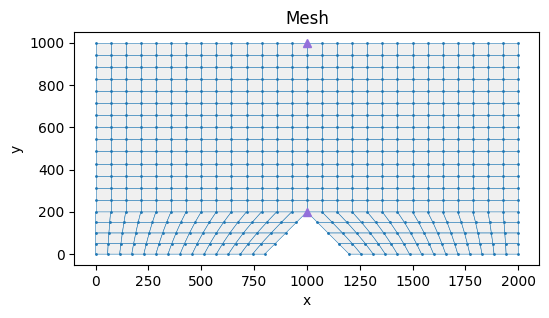

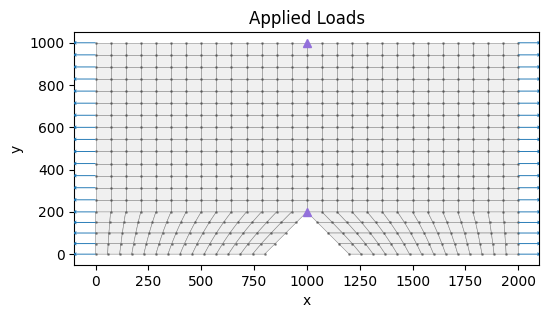

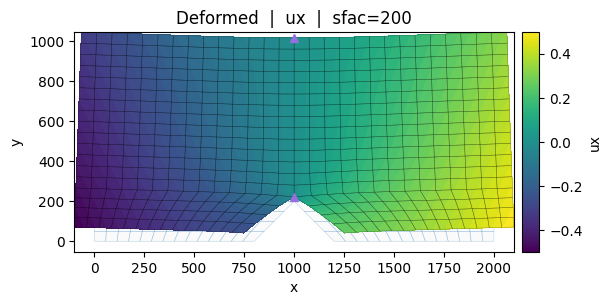

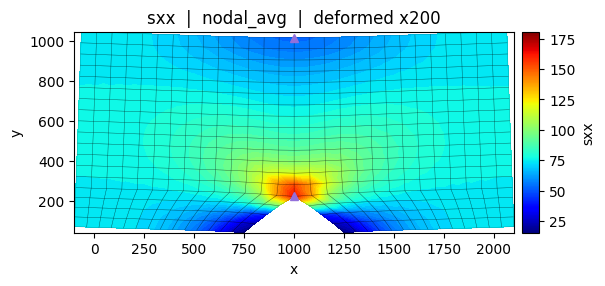

In [23]:
# Mesh
plot_mesh(
    nodes               = nodes,
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,   
)


# Loads
plot_loads_2d(
    nodes    = nodes,
    elements = elements,
    F_load   = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize  = (6, 6),
    ax       = None,
    save     = None,    
)

# Deformed
plot_deformed(
    nodes     = nodes,
    elements  = elements,
    u         = u,
    component = 'ux',   # 'ux', 'uy', 'umag'
    sfac      = 200,
    cmap      = 'viridis',
    limit               = None,      
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes       = nodes,
    elements    = elements,
    u           = u,
    component   = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed    = True,
    sfac        = 200,
    limit       = None,         # e.g. (-250, 250) highlights elements outside range in red
    # levels      = 20,
    cmap        = 'jet',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)